In [117]:
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import entropy
import itertools
import matplotlib
matplotlib.rcParams.update({'font.size': 8})

NOTES/TODO:
use entropy of variances to measure how distributed the code is for different angles
drop/out of high variance cells to see if we can still decode the angles? - distribution of prediction accuracy
compare the coefficients in dot product with less crossvalidated - fewer overlapping points

a digression into plotting linear shift

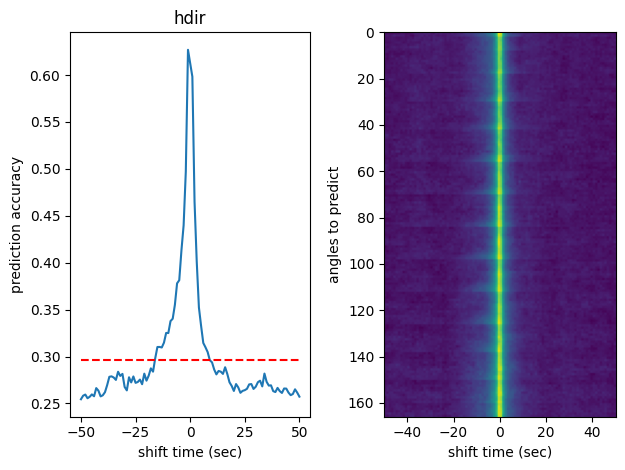

In [25]:
'''A small section to check what linear shift prediction accuracy looks like'''

pp = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all\shelter_present\good_shelter_present_LDA_LS_prediction_accuracy.pkl"
with open(pp, "rb") as dill_file:
    LS = pickle.load(dill_file)

fig, axs = plt.subplots(1,2)
axs[0].plot(LS['hdir'].shifts/40, LS['hdir'].pseudo_stats)
axs[0].plot([-50,50],[np.mean(LS['hdir'].pseudo_stats),np.mean(LS['hdir'].pseudo_stats)],'--r')
axs[0].set_xlabel('shift time (sec)')
axs[0].set_ylabel('prediction accuracy')
axs[0].set_title('hdir')

shifty = np.empty((len(LS['hdir'].shifts),len(LS.keys())))
for c,i in enumerate(LS.keys()):
    shifty[:,c] = LS[i].pseudo_stats
axs[1].imshow(shifty.T, extent = [LS['hdir'].shifts[0]/40,LS['hdir'].shifts[-1]/40,len(LS.keys()),0])
axs[1].set_xlabel('shift time (sec)')
axs[1].set_ylabel('angles to predict')
plt.tight_layout()

some plotting of LDA coefficient

In [ ]:
base_path = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all"
conditions = ['pre_shelter','shelter_present']
all_angles = ['hdir','hsa']

In [121]:
base_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_bar_north_a','h_bar_south_a']

In [123]:
# load in coef

coef = {}
for i in conditions:
    coef_path = os.path.join(base_path,i,str('good_' + i + '_LDA_prediction_coef.pkl'))
    with open(coef_path, "rb") as dill_file:
        coef[i] = pickle.load(dill_file)
n_cells = np.shape(coef[conditions[0]]['hdir'])[1]

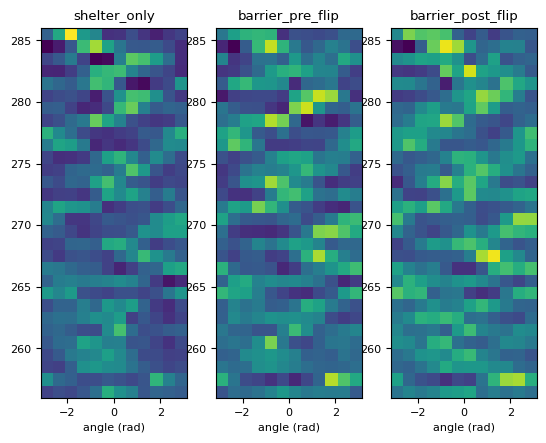

In [124]:
'''a look at the coefficients with the greatest variance'''
fig, axs = plt.subplots(1,len(conditions))
angle = 'hsa' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(coef['shelter_only'][angle], axis = 0))
for c,i in enumerate(conditions):
    axs[c].imshow(coef[i][angle][:,peak_weight].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
    axs[c].set_title(i)

for i in np.arange(len(conditions)):
    axs[i].set_ylim((n_cells-30,n_cells))
    axs[i].set_xlabel('angle (rad)')

Text(0.5, 1.0, 'cluster 4')

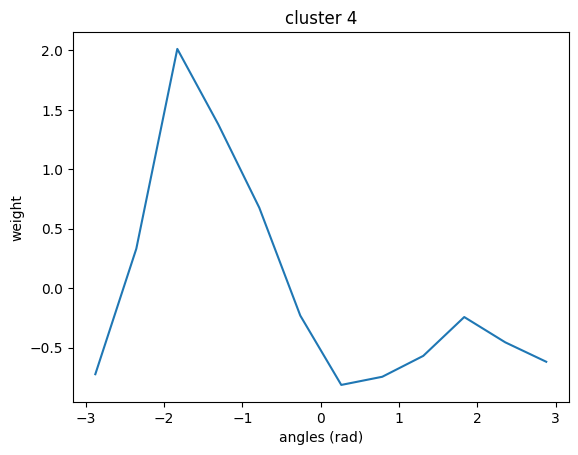

In [59]:
'''an example cluster's weights'''
cluster_Ids = np.load(r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\good_cluster_Ids.npy")
angle = 'hdir' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(coef['pre_shelter'][angle], axis = 0))
clu_choice = peak_weight[-1]
# clu_choice = int(np.where(cluster_Ids == 109)[0])
bin_angles = np.linspace(-np.pi, np.pi, 13)
bin_angle_center = np.sort(np.append([-np.pi, np.pi], [bin_angles[:-1] + (np.mean(np.diff(bin_angles)) / 2)]))
plt.plot(bin_angle_center[1:-1],coef['pre_shelter'][angle][:,clu_choice])
plt.ylabel('weight')
plt.xlabel('angles (rad)')
plt.title('cluster '+str(cluster_Ids[clu_choice]))

Text(0.5, 1.0, 'hsa')

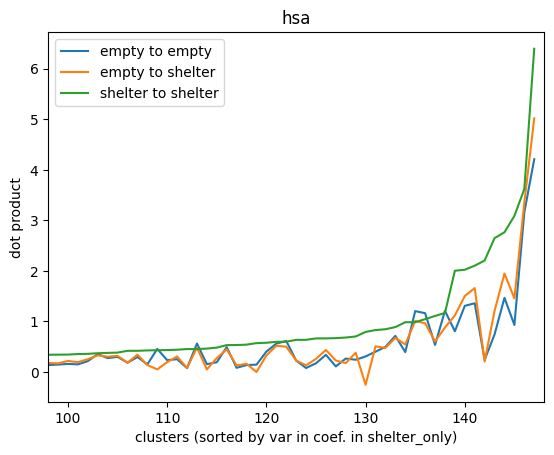

In [104]:
'''a look at the dot product between coefficients sorted by variance'''
angle = 'hsa' # 'h_bar_south_a', 'hdir', 'hsa'
peak_weight = np.argsort(np.var(coef['shelter_present'][angle], axis = 0))
d_prod = np.empty(n_cells)
for i in np.arange(n_cells):
    d_prod[i] = np.dot(coef['pre_shelter'][angle][:,i], coef['pre_shelter'][angle][:,i])
plt.plot(d_prod[peak_weight])
for i in np.arange(n_cells):
    d_prod[i] = np.dot(coef['pre_shelter'][angle][:,i], coef['shelter_present'][angle][:,i])
plt.plot(d_prod[peak_weight])
for i in np.arange(n_cells):
    d_prod[i] = np.dot(coef['shelter_present'][angle][:,i], coef['shelter_present'][angle][:,i])
plt.plot(d_prod[peak_weight])
plt.legend(['empty to empty','empty to shelter','shelter to shelter'])
plt.xlim((n_cells - 50,n_cells))
plt.xlabel('clusters (sorted by var in coef. in shelter_only)')
plt.ylabel('dot product')
plt.title(angle)

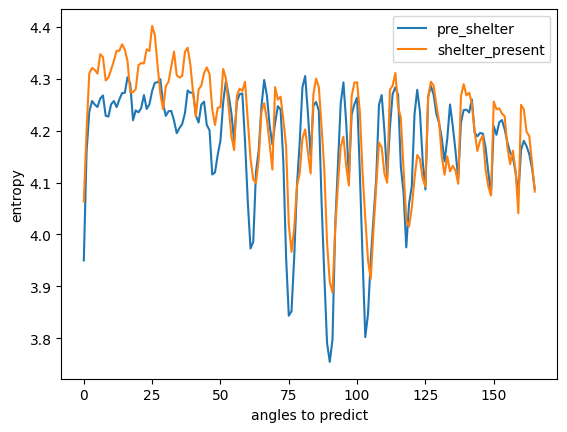

In [65]:
'''a quick look at entropy'''
all_angles = coef['pre_shelter'].keys()#['hdir','hsa','h_bar_north_a','h_bar_south_a']
var_weight = np.empty((len(conditions),len(all_angles)))
for idx,c in enumerate(conditions):
    for i,angle in enumerate(all_angles):
        var = np.var(coef[c][angle], axis = 0)
        var_weight[idx,i] = entropy(var/np.sum(var))
plt.plot(var_weight.T)
plt.ylabel('entropy')
plt.xlabel('angles to predict')
plt.legend(conditions)

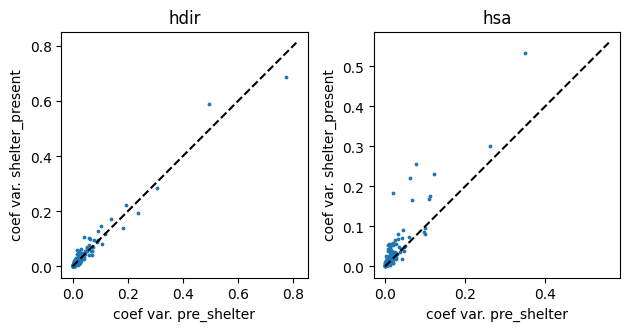

In [101]:
'''a look at coefficient variance across conditions'''

for i,angle in enumerate(all_angles):
    for j, c in enumerate(conditions[:-1]):
        ax = plt.subplot2grid(shape=(len(conditions)-1,len(all_angles)), loc=(j, i))
        ax.scatter(np.var(coef[c][angle], axis = 0),
                        np.var(coef[conditions[j+1]][angle],axis = 0)
                        ,s=3)
        ax.set_xlabel('coef var. ' + c)
        ax.set_ylabel('coef var. ' + conditions[j+1])
        ax.plot([0,np.amax(np.array([ax.get_xlim()[1],ax.get_ylim()[1]]))],[0,np.amax(np.array([ax.get_xlim()[1],ax.get_ylim()[1]]))],'--k')
        ax.set_title(angle)
        ax.set_aspect('equal','box')
plt.tight_layout()

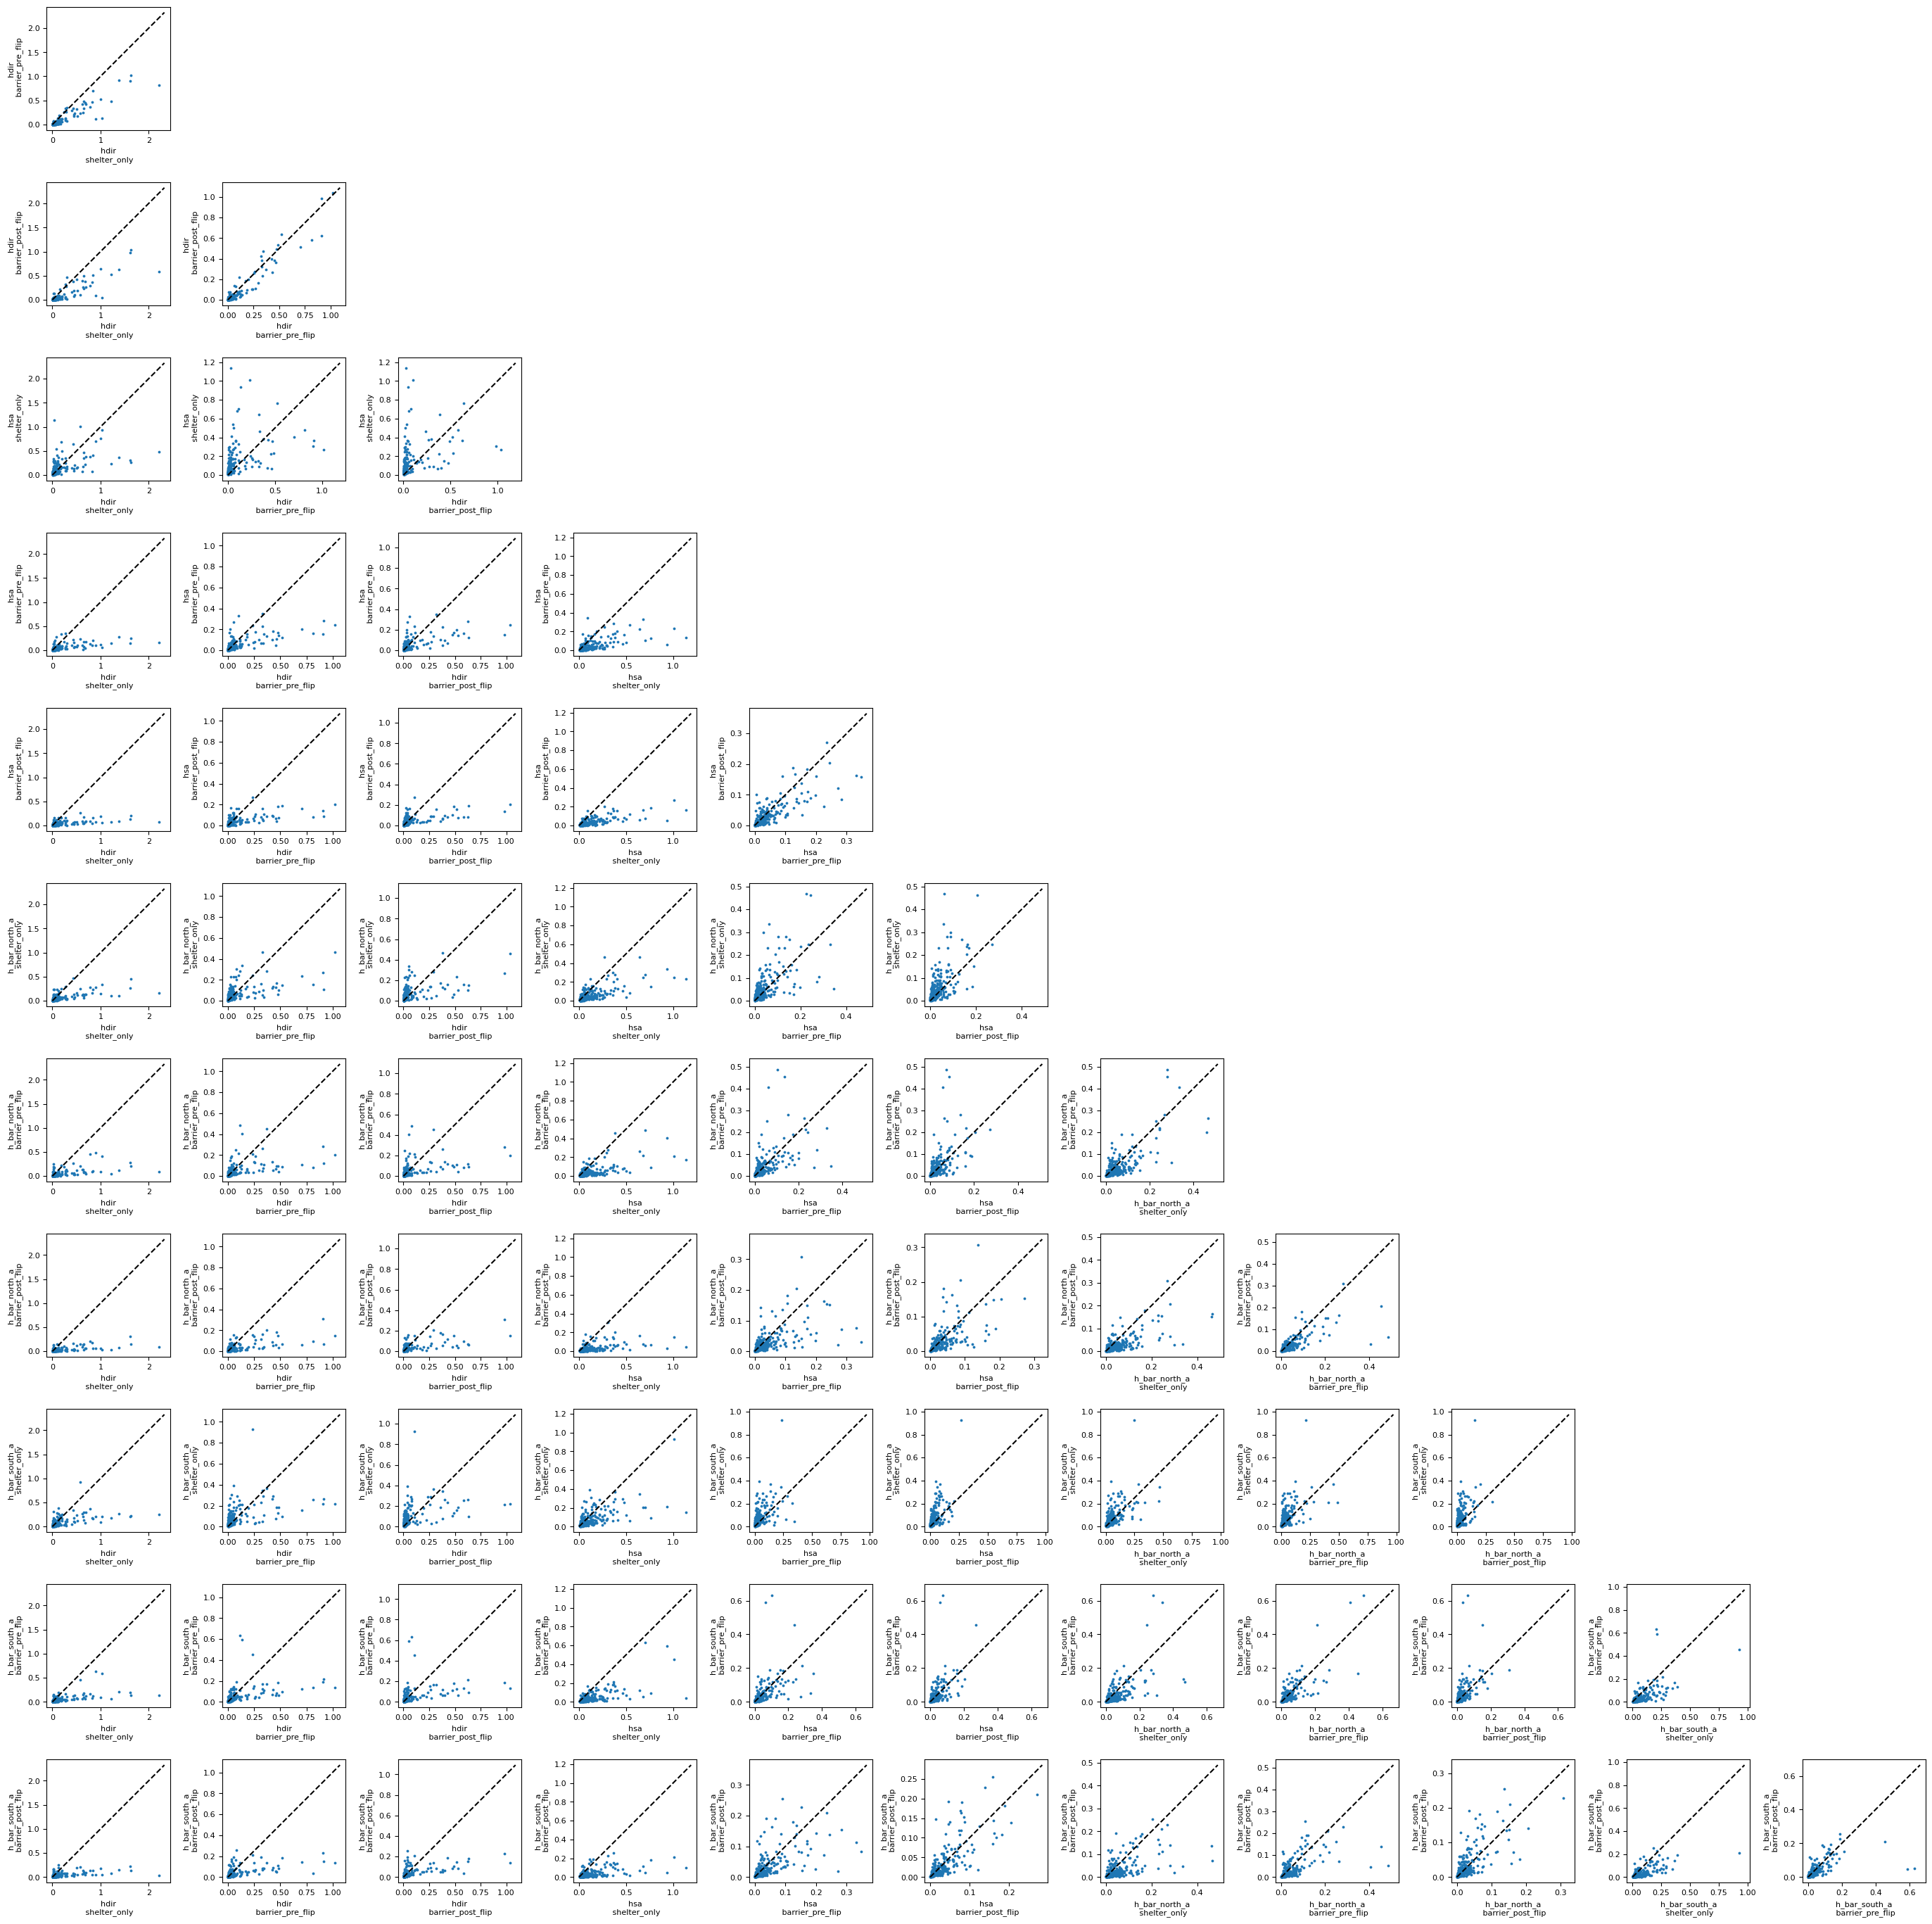

In [131]:
'''a look at coefficient variance across angles and conditions'''
unique = list(itertools.product(all_angles, conditions))
matplotlib.rcParams.update({'font.size': 8})
for c1,i in enumerate(unique):
    for c2,j in enumerate(unique):
        if c2>c1:
            ax = plt.subplot2grid(shape=(len(unique),len(unique)), loc=(c2, c1))
            ax.scatter(np.var(coef[i[1]][i[0]], axis = 0),
                            np.var(coef[j[1]][j[0]],axis = 0)
                            ,s=3)
            ax.set_xlabel(i[0] + '\n ' + i[1])
            ax.set_ylabel(j[0] + '\n ' + j[1])
            ax.plot([0,np.amax(np.array([ax.get_xlim()[1],ax.get_ylim()[1]]))],[0,np.amax(np.array([ax.get_xlim()[1],ax.get_ylim()[1]]))],'--k')
            ax.set_aspect('equal','box')
plt.rcParams['figure.figsize'] = [30, 30]
plt.tight_layout()

Let's look at dropout prediction acuracy

In [66]:
import matplotlib.pyplot as plt
import dill as pickle
import numpy as np

In [83]:
base_path = r"W:\branco\Laurence\JAL008\JAL008_empty_shelter2_2024_04_22T10_51_22\processed_data\models\LDA_fr_excl_prox_15cm\good\experimental_conditions\all"
condition = 'pre_shelter'# 'pre_shelter'
LDA_path = os.path.join(base_path,condition,str('good_' + condition + '_LDA_prediction_accuracy.pkl'))
with open(LDA_path, "rb") as dill_file:
    pa = pickle.load(dill_file)
dropout_path = os.path.join(base_path,condition,str('good_' + condition + '_LDA_dropout_pa.pkl'))
with open(dropout_path, "rb") as dill_file:
    dropout_pa = pickle.load(dill_file)
coef_path = os.path.join(base_path,condition,str('good_' + condition + '_LDA_prediction_coef.pkl'))
with open(coef_path, "rb") as dill_file:
    coef = pickle.load(dill_file)

Text(0.5, 1.0, 'pre_shelter')

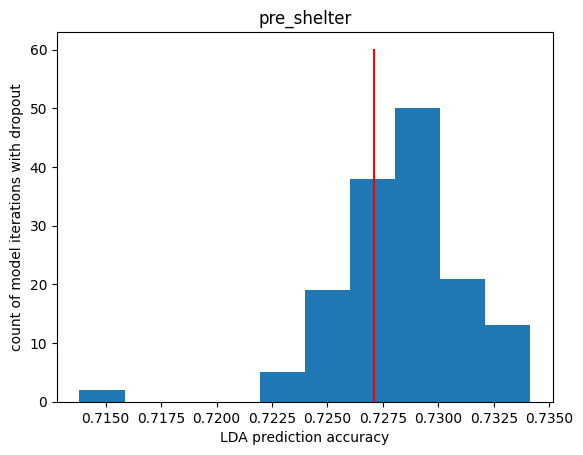

In [85]:
'''a histogram of prediction accuracy for each dropout - in red is the full model'''
angle = 'hsa'
plt.hist(dropout_pa[angle])
plt.plot([pa[angle],pa[angle]],[0,60],'r')
plt.xlabel('LDA prediction accuracy')
plt.ylabel('count of model iterations with dropout')
plt.title(condition)

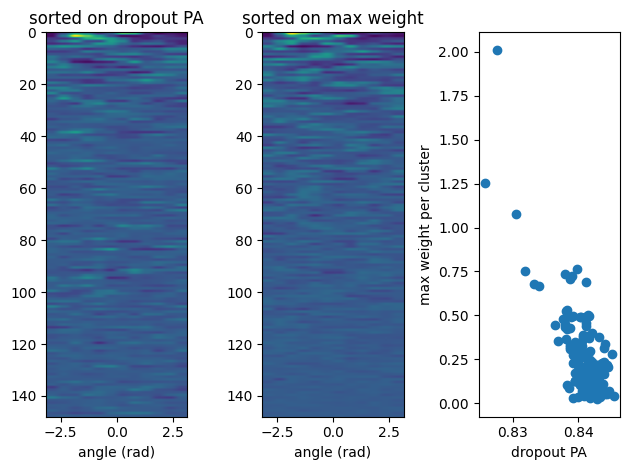

In [76]:
'''LDA coefficients sorted by dropout prediction accuracy'''
angle = 'hdir'
fig, axs = plt.subplots(1,3)
axs[0].imshow(coef[angle][:,np.argsort(dropout_pa[angle])].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
axs[0].set_xlabel('angle (rad)')
axs[0].set_title('sorted on dropout PA')
axs[1].imshow(coef[angle][:,np.flipud(np.argsort(np.amax(coef[angle],axis = 0)))].T,aspect = 'auto',extent = [-np.pi,np.pi,n_cells,0])
axs[1].set_xlabel('angle (rad)')
axs[1].set_title('sorted on max weight')
axs[2].scatter(dropout_pa[angle],np.amax(coef[angle],axis = 0))
axs[2].set_xlabel('dropout PA')
axs[2].set_ylabel('max weight per cluster')
plt.tight_layout()